***
## Related Package Load
***

In [1]:
import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import scipy.stats as scs
plt.style.use('seaborn-v0_8-whitegrid')
# Set up the display digit in pandas dataframe
pd.options.display.float_format = "{:,.7f}".format

***
## 1. Solution to Systems of Linear Equations
***

$\displaystyle A = L + U$  

$\displaystyle x^{(r+1)} = L^{-1}\left(b - Ux^{(r)} \right)$

In [2]:
# Matrix - based formula
def Gauss_Siedel(A,b,x,tol = 1e-3):
	L = np.tril(A)
	U = A - L
	count = 0
	print('init x: {:.4f} {:.4f} {:.4f}'.format(*x.ravel()))
	while True:
		xc = inv(L) @ (b - (U @ x))
		count += 1
		if np.sqrt((xc - x).T @ (xc - x)) < tol:
			print('it converged \n')
			break
		rpt_str = f'iter {count}'
		rpt_str += ': {:.4f} {:.4f} {:.4f}'.format(*xc.ravel())
		print(rpt_str)
		x = xc
	return x

In [3]:
# Check diagonally dominant
def DD_check(M):
    diag = np.diag(np.abs(M))
    off_diag = np.sum(np.abs(M),axis = 1) - diag
    if np.all(diag > off_diag):
        print(f'Matrix is diagonally dominant')
    else:
        print('Not diagonally dominant')

In [4]:
A = np.array([[ 8, 3,-3],
			  [-2,-8, 5],
			  [ 3, 5,10]])
DD_check(A)  # 如果是嚴格對角優勢矩陣才會收斂。

Matrix is diagonally dominant


In [5]:
b = np.array([[14],
			   [5],
			  [-8]])
x = np.zeros((3,1))
res_conv = Gauss_Siedel(A,b,x)
print('converged result is \n (x1,x2,x3) = ({},{},{})'.format(*res_conv.ravel()))

init x: 0.0000 0.0000 0.0000
iter 1: 1.7500 -1.0625 -0.7938
iter 2: 1.8508 -1.5838 -0.5633
iter 3: 2.1327 -1.5103 -0.6847
iter 4: 2.0596 -1.5678 -0.6340
iter 5: 2.1002 -1.5463 -0.6569
iter 6: 2.0835 -1.5565 -0.6468
iter 7: 2.0911 -1.5520 -0.6513
iter 8: 2.0878 -1.5540 -0.6493
iter 9: 2.0893 -1.5531 -0.6502
it converged 

converged result is 
 (x1,x2,x3) = (2.0892575740758335,-1.5531431846137482,-0.6502056799158761)


***
## 2. Numerical Integration
***

$\displaystyle \int_{0}^{\pi} \sin(x) dx = \pi \int_{0}^{\pi} \frac{\sin(x)}{\pi} dx = \pi E(\sin(U))$ where $U \sim U(0,\pi)$

In [6]:
class int_kit:
	def __init__(self,fn,area: list,n: int):
		a,b = area
		self.fn = fn
		self.height = (b - a) / (n - 1)
		self.grid = np.linspace(a,b,n)
	
	def Midpt(self):
		f = self.fn
		x = self.grid
		h = self.height
		return np.sum(h * f((x[:-1] + x[1:]) / 2)).item()
	
	def Trapezoid(self):
		f = self.fn
		x = self.grid
		h = self.height
		return np.sum((h / 2) * (f(x[:-1]) + f(x[1:]))).item()
	
	@staticmethod
	def ARE(est,tval):
		return np.abs((tval - est) / est) * 100
	
	@staticmethod
	def MCMC(f,area: list,runs: int):
		a,b = area
		x = np.random.uniform(a,b,runs)
		return ((sum(f(x)) / runs) * np.pi).item()


In [7]:
f = lambda x:np.sin(x)
area = [0,np.pi]
seqN = [11,101,1001,10001]
tval = 2
dr = []
for n in seqN:
    num_int = int_kit(f,area,n)
    m1 = num_int.Midpt()
    m2 = num_int.Trapezoid()
    rel1 = int_kit.ARE(m1,tval)
    rel2 = int_kit.ARE(m2,tval)
    dr.append([m1,rel1,m2,rel2])
df = pd.DataFrame(dr,
                  columns = ['Midpoint','ARE-Midpoint(%)','Trapezoid','ARE-Trapezoid(%)'],
                  index = [f'n = {n}' for n in seqN])
display(df)

,Midpoint,ARE-Midpoint(%),Trapezoid,ARE-Trapezoid(%)
n = 11,2.0082484,0.4107265,1.9835235,0.8306663
n = 101,2.0000822,0.0041123,1.9998355,0.0082255
n = 1001,2.0000008,0.0000411,1.9999984,0.0000822
n = 10001,2.0000000,0.0000004,2.0000000,0.0000008


***
## Why in this case Midpoint Rule > Trapeziod Rule?
***
Let $\Phi(\cdot)$ be concave function than  

$\displaystyle \Phi(\alpha x + (1-\alpha)y) \geq \alpha \Phi(x) + (1-\alpha) \Phi(y)$ where $\alpha \in (0,1)$ and $x \neq y$  

Since the sine on $[0,\pi]$ is concave function  

$\displaystyle f\left(\frac{x_i}{2} + \frac{x_{i+1}}{2}\right) \geq \frac{1}{2}f(x_i) + \frac{1}{2}f(x_{i+1})$

In [8]:
seqR = [100,1000,10000,100000]
for r in seqR:
    mc = int_kit.MCMC(f,area,r)
    print(f'runs = {r}, est = {mc}')

runs = 100, est = 2.0297046513632138
runs = 1000, est = 1.9857785045884202
runs = 10000, est = 2.0018879977372794
runs = 100000, est = 1.997353717167643


***
## 3. Gradient Descend Method
***

$\displaystyle g(\theta_1,\theta_2) = \frac{9}{16}(\theta_1-2)^2 +(\theta_2 -2)^2 + \frac{\theta_1 \theta_2}{4}$  

$\displaystyle \nabla_{g} = [\frac{\partial g}{\partial \theta_1},\frac{\partial g}{\partial \theta_2}]^{\top}$

$\displaystyle \frac{\partial g}{\partial \theta_1} = \frac{9}{8}(\theta_1 - 2) + \frac{\theta_2}{4}$  

$\displaystyle \frac{\partial g}{\partial \theta_2} = 2(\theta_2-2) + \frac{\theta_1}{4}$  

In [9]:
class Grad_Tool:
	def __init__(self,fn,pt: list,maxN: int):
		self.fn = fn
		self.pt = pt
		self.maxN = maxN
		
	@staticmethod
	def grad_f(dx,dy):
		df_dx = (9/8) * (dx - 2) + (dy / 4)  # 對 x 偏微
		df_dy = 2 * (dy - 2) + (dx / 4)  # 對 y 偏微
		return np.array([df_dx,df_dy])  # 回傳 Gradiant

	def GradD(self,alpha: float):
		init_pt = np.array(self.pt)
		iter_res = np.zeros((self.maxN + 1,2))  # 紀錄每一步的 x, y 座標
		iter_res[0,:] = init_pt
		vec = init_pt
		for k in range(1,self.maxN + 1):
			vec = vec - alpha * Grad_Tool.grad_f(*vec)  # 計算目前位置的梯度，乘上學習率 alpha，然後用目前位置 vec 減去它，得到新的位置，並覆蓋掉 vec。
			iter_res[k,:] = vec
		return iter_res
	
	def Momentum(self,alpha: float):
		init_pt = np.array(self.pt)
		iter_res = np.zeros((self.maxN + 1,2))
		vec = init_pt
		iter_res[0,:] = init_pt
		wgt = np.zeros(2)
		for k in range(1,self.maxN + 1):
			wgt = 0.9 * wgt + Grad_Tool.grad_f(*vec)
			vec = vec - alpha * wgt 
			iter_res[k,:] = vec
		return iter_res

In [10]:
# case of learning rate
alpha_set = [0.01,0.1,0.2,0.3,0.5,0.75]
# initial position
pt = [5,4]
a,b = [0,5]
nd = 26
grids = np.linspace(a,b,26)
# objective function
f = lambda x,y:(9/16) * ((x - 2) ** 2) + (y - 2) ** 2 + (x*y / 4)
grad_kit = Grad_Tool(f,pt,10)
plt.figure(figsize = [11,8])
saver = []
for k,alpha in enumerate(alpha_set,start = 1):
	vec = grad_kit.GradD(alpha)
	df = pd.DataFrame(grad_kit.GradD(alpha),
				      index = ['init pt'] + [f'iter {k}' for k in range(1,11)],
					  columns = [f'({alpha},theta1)',f'({alpha},theta2)'])
	saver.append(df)
pd.concat(saver,axis = 1)

,"(0.01,theta1)","(0.01,theta2)","(0.1,theta1)","(0.1,theta2)","(0.2,theta1)","(0.2,theta2)","(0.3,theta1)","(0.3,theta2)","(0.5,theta1)","(0.5,theta2)","(0.75,theta1)","(0.75,theta2)"
init pt,5.0000000,4.0000000,5.0000000,4.0000000,5.0000000,4.0000000,5.0000000,4.0000000,5.0000000,4.0000000,5.0000000,4.0000000
iter 1,4.9562500,3.9475000,4.5625000,3.4750000,4.1250000,2.9500000,3.6875000,2.4250000,2.8125000,1.3750000,1.7187500,0.0625000
iter 2,4.9131234,3.8961594,4.1873438,3.0659375,3.4993750,2.3637500,2.9360937,1.8934375,2.1835938,1.6484375,1.9443359,2.6464844
iter 3,4.8706104,3.8459534,3.8646191,2.7480664,3.0438281,2.0432812,2.4781543,1.7371680,1.8742676,1.7270508,1.4950867,1.3121948
iter 4,4.8287011,3.7968578,3.5861478,2.5018376,2.7068027,1.8737773,2.1864896,1.7090056,1.7291107,1.7657166,1.6750708,2.0635738
iter 5,4.7873861,3.7488489,3.3451603,2.3118164,2.4540833,1.7889263,1.9953740,1.7196155,1.6607714,1.7838612,1.5623097,1.6541373
iter 6,4.7466559,3.7019034,3.1360343,2.1658241,2.2624682,1.7506516,1.8679641,1.7381932,1.6286048,1.7924036,1.6214601,1.8799983
iter 7,4.7065013,3.6559987,2.9540849,2.0542584,2.1158803,1.7372675,1.7821617,1.7551800,1.6134642,1.7964244,1.5883535,1.7559771
iter 8,4.6669131,3.6111125,2.7953938,1.9695546,2.0029438,1.7365665,1.7240436,1.7684099,1.6063375,1.7983170,1.6064345,1.8241952
iter 9,4.6278826,3.5672230,2.6566732,1.9057589,1.9154532,1.7417927,1.6845482,1.7780607,1.6029830,1.7992078,1.5964688,1.7866959


<Figure size 1100x800 with 0 Axes>

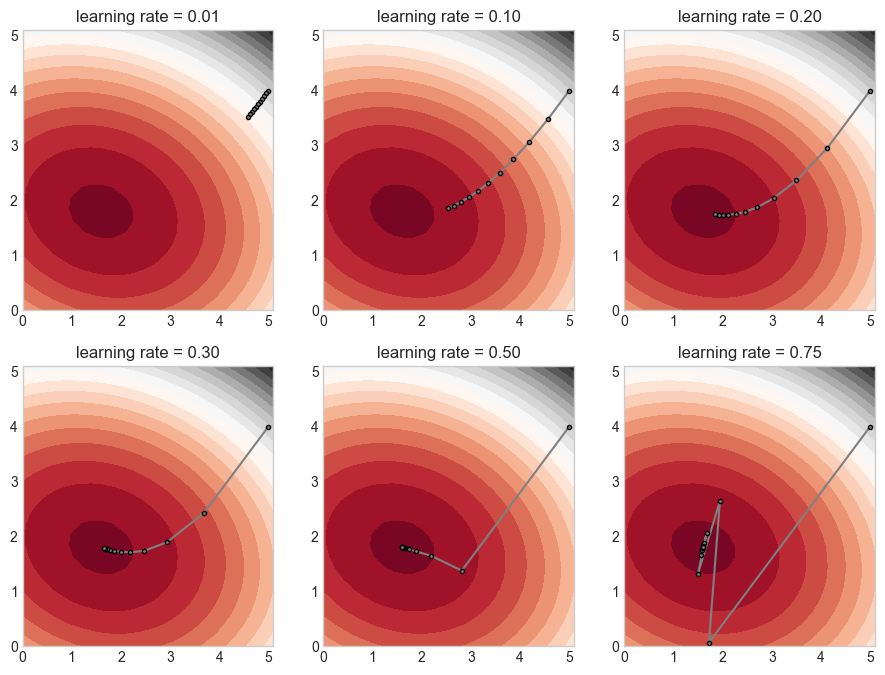

In [21]:
plt.figure(figsize = [11,8])
for k,alpha in enumerate(alpha_set,start = 1):
	vec = grad_kit.GradD(alpha)
	grid = np.linspace(a,b+0.1,nd)
	# generate tuple of coordinate matrices from coordinate vec
	x,y = np.meshgrid(grid,grid)
	z = f(x,y)
	lv_set = np.linspace(0,int(np.ceil(np.max(z))),21)
	plt.subplot(2,3,k)
	plt.title(f'learning rate = {alpha:.2f}')
	plt.contourf(x,y,z,levels = lv_set,cmap = 'RdGy')
	plt.plot(vec[:,0],vec[:,1],color = 'grey',marker = '.',mec = 'black')

In [12]:
pd.DataFrame(grad_kit.Momentum(0.5),
             index = ['init pt'] + [f'iter {k}' for k in range(1,11)],
             columns = [f'(0.5,theta1)',f'(0.5,theta2)'])

,"(0.5,theta1)","(0.5,theta2)"
init pt,5.0000000,4.0000000
iter 1,2.8125000,1.3750000
iter 2,0.2148438,-0.7140625
iter 3,-1.0296387,0.0929883
iter 4,-0.4571246,2.8550505
iter 5,1.0833893,4.5429966
iter 6,2.4175708,3.3837278
iter 7,2.9604846,0.6544617
iter 8,2.8270267,-0.8264000
iter 9,2.3450121,0.3138461


***
## 4. Encryptin Alphabetic Text
***

In [13]:
class Encrypt_Tool:
    @staticmethod
    def encode_each(alpbet: str,key: str) -> str:
        abase = ord('A') if alpbet.isupper() else ord('a')
        kbase = ord('A') if key.isupper() else ord('a')
        T = ord(alpbet) - abase
        K = ord(key) - kbase
        E = (T + K) % 26
        return chr(abase + E)
    
    @staticmethod
    def Vigenere_Cipher(plain_text: str,keyword: str) -> str:
        res_text = ""
        count = 0
        for T in plain_text:
            if T.isalpha():
                K = keyword[count % len(keyword)]
                res_text += Encrypt_Tool.encode_each(T,K)
                count += 1
            else:
                res_text += T
        return res_text
    
    @staticmethod
    def Caeser_Cipher(plain_text: str,shift: str|int) -> str:
        key = shift.upper() if isinstance(shift,str) else chr(65 + shift)
        return Encrypt_Tool.Vigenere_Cipher(plain_text,key)
    
    @staticmethod
    def Crack_Text(plain_txt: str):
        for k in range(26):
            print(k,Encrypt_Tool.Caeser_Cipher(plain_txt,26-k))

In [14]:
plain_text1 = 'HELLO EVERYONE'
Encrypt_Tool.Caeser_Cipher(plain_text1,6)

'NKRRU KBKXEUTK'

In [15]:
plain_text2 = 'attack at dawn'
Encrypt_Tool.Vigenere_Cipher(plain_text2,'LEMON')

'lxfopv ef rnhr'

In [16]:
plain_text3 = 'exxego ex srgi'
Encrypt_Tool.Crack_Text(plain_text3)

0 yrryai yr mlac
1 dwwdfn dw rqfh
2 cvvcem cv qpeg
3 buubdl bu podf
4 attack at once
5 zsszbj zs nmbd
6 yrryai yr mlac
7 xqqxzh xq lkzb
8 wppwyg wp kjya
9 voovxf vo jixz
10 unnuwe un ihwy
11 tmmtvd tm hgvx
12 sllsuc sl gfuw
13 rkkrtb rk fetv
14 qjjqsa qj edsu
15 piiprz pi dcrt
16 ohhoqy oh cbqs
17 nggnpx ng bapr
18 mffmow mf azoq
19 leelnv le zynp
20 kddkmu kd yxmo
21 jccjlt jc xwln
22 ibbiks ib wvkm
23 haahjr ha vujl
24 gzzgiq gz utik
25 fyyfhp fy tshj


***
## 5. Association Measure
***

$H_0$: X and Y are independent

In [17]:
class association_measure:
    def __init__(self,X,Y):
        self.X = np.array(X)
        self.Y = np.array(Y)
            
    def rho(self):
        'Spearman Rho'
        n = len(self.X)
        rX = self.X.argsort().argsort()
        rY = self.Y.argsort().argsort()
        rd = rX - rY
        coef = 1 - ((6 * sum(rd**2)) / (n*(n**2 - 1))).item()
        tQ = coef * np.sqrt((n - 2) / (1 - coef**2))
        pval = 2*(1 - scs.t.cdf(np.abs(tQ),n - 2)).item()
        return coef,pval

    def tau(self):
        'Kendall Tau'
        n = len(self.X)
        cSum = 0
        for (i,j) in combinations(range(n),2):
            sX = np.sign(self.X[i] - self.X[j])
            sY = np.sign(self.Y[i] - self.Y[j])
            prod = sX * sY
            cSum += prod
        coef = ((2 * cSum) / (n * (n-1))).item()
        upper = 9 * n * (n-1)
        lower = 2 * (2*n + 5)
        tQ = coef * np.sqrt(upper / lower)
        pval = 2*(1 - scs.norm.cdf(np.abs(tQ))).item()
        return coef,pval


In [18]:
X = [106,100,86,101,99,103,97,113,112,110]
Y = [7,27,2,50,28,29,20,12,6,17]
assM = association_measure(X,Y)
for opr in ['.rho','.tau']:
    Nm = eval(f'assM{opr}.__doc__')
    coef,pval = eval(f'assM{opr}()')
    print(f'{Nm} = {coef:.4f} with p-value = {pval:.4f}')

Spearman Rho = -0.1758 with p-value = 0.6272
Kendall Tau = -0.1111 with p-value = 0.6547


In [19]:
coef,pval = scs.spearmanr(X,Y)
print(f'Spearman Rho = {coef:.4f} with p-value = {pval:.4f}')
coef,pval = scs.kendalltau(X,Y,method = 'asymptotic')
print(f'Kendall Tau = {coef:.4f} with p-value = {pval:.4f}')

Spearman Rho = -0.1758 with p-value = 0.6272
Kendall Tau = -0.1111 with p-value = 0.6547
